In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Generate a non-linear dataset (concentric circles)
X, y = make_circles(n_samples=500, factor=0.3, noise=0.15, random_state=42)
df = pd.DataFrame(X, columns=['Feature1', 'Feature2'])
df['Target'] = y

# Inject artificial outliers to test the Z-score removal
outliers = pd.DataFrame({
    'Feature1': [4.5, -4.0, 5.0],
    'Feature2': [-5.0, 4.2, 4.8],
    'Target': [0, 1, 0]
})
df = pd.concat([df, outliers], ignore_index=True)
print("Data loaded successfully!")

Data loaded successfully!


Block 2: Exploratory Data Analysis (EDA)

----- BEFORE PREPROCESSING -----

1. Shape: (503, 3)

2. Data Types:
 Feature1    float64
Feature2    float64
Target        int64
dtype: object

3. Missing Values:
 Feature1    0
Feature2    0
Target      0
dtype: int64

4. Summary Statistics:
          Feature1    Feature2      Target
count  503.000000  503.000000  503.000000
mean     0.024462    0.011953    0.499006
std      0.645504    0.645901    0.500497
min     -4.000000   -5.000000    0.000000
25%     -0.320242   -0.298198    0.000000
50%      0.025733    0.003188    0.000000
75%      0.343354    0.334123    1.000000
max      5.000000    4.800000    1.000000


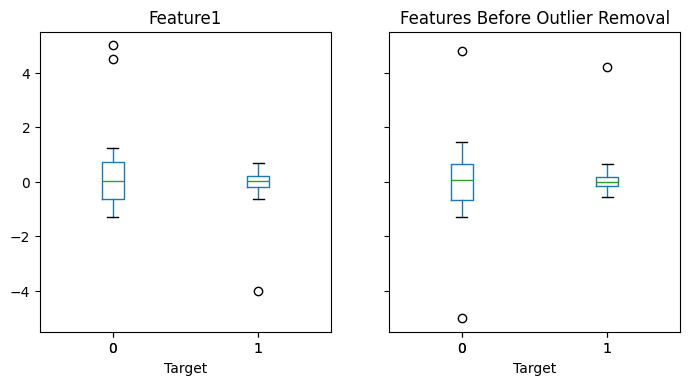

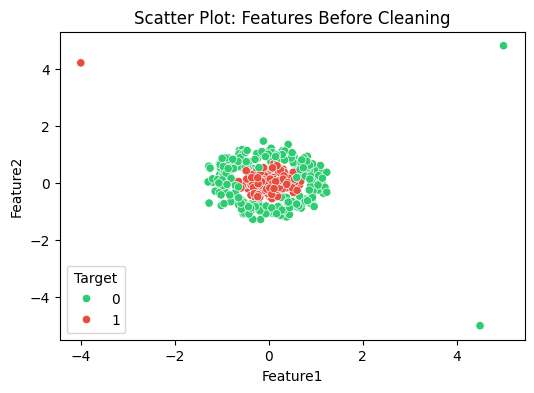

In [2]:
print("----- BEFORE PREPROCESSING -----\n")
print("1. Shape:", df.shape)
print("\n2. Data Types:\n", df.dtypes)
print("\n3. Missing Values:\n", df.isnull().sum())
print("\n4. Summary Statistics:\n", df.describe())

# Visualizations
df.boxplot(column=['Feature1', 'Feature2'], by='Target', grid=False, figsize=(8,4))
plt.title("Features Before Outlier Removal")
plt.suptitle("")
plt.show()

plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='Feature1', y='Feature2', hue='Target', palette=["#2ecc71", "#e74c3c"])
plt.title("Scatter Plot: Features Before Cleaning")
plt.show()

Block 3: Preprocessing (Outlier Removal)

Total outliers removed: 3
Total rows after outlier removal: 500



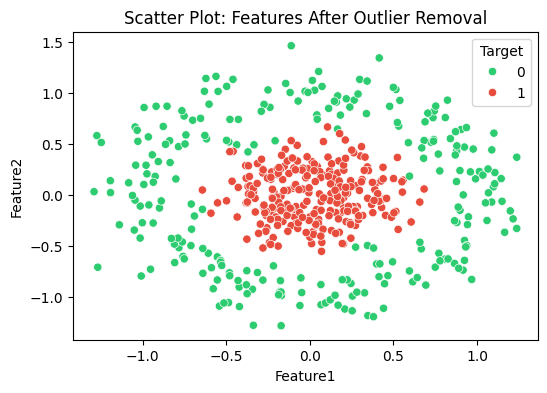

In [3]:
df_clean = df.dropna().copy()
total_rows_before = len(df_clean)

# Find and remove outliers using Z-score (> 3 standard deviations)
z_scores = np.abs(stats.zscore(df_clean[['Feature1', 'Feature2']]))
df_clean = df_clean[(z_scores < 3).all(axis=1)].reset_index(drop=True)

total_rows_after = len(df_clean)
print(f"Total outliers removed: {total_rows_before - total_rows_after}")
print(f"Total rows after outlier removal: {total_rows_after}\n")

# Visualization After
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df_clean, x='Feature1', y='Feature2', hue='Target', palette=["#2ecc71", "#e74c3c"])
plt.title("Scatter Plot: Features After Outlier Removal")
plt.show()

Block 4: Data Splitting & Plotting Setup

In [5]:
# Prepare data for SVM
X_clean = df_clean[['Feature1', 'Feature2']].values
y_clean = df_clean['Target'].values

X_train, X_test, y_train, y_test = train_test_split(X_clean, y_clean, test_size=0.2, random_state=42)

# Create a mesh grid to plot the decision boundaries later
x_min, x_max = X_clean[:, 0].min() - 0.5, X_clean[:, 0].max() + 0.5
y_min, y_max = X_clean[:, 1].min() - 0.5, X_clean[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

print("Data split into training and testing sets. Ready for models!")

Data split into training and testing sets. Ready for models!


Block 5: Linear Kernel Implementation

Linear Kernel Accuracy: 43.00%


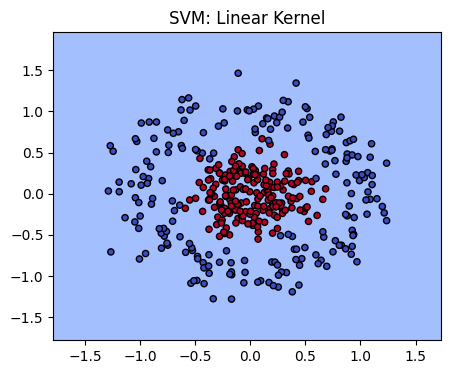

In [6]:
# Train Linear Kernel
linear_model = SVC(kernel='linear', C=1.0)
linear_model.fit(X_train, y_train)

# Calculate Accuracy
linear_acc = accuracy_score(y_test, linear_model.predict(X_test))
print(f"Linear Kernel Accuracy: {linear_acc * 100:.2f}%")

# Visualize
plt.figure(figsize=(5, 4))
Z_linear = linear_model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
plt.contourf(xx, yy, Z_linear, cmap=plt.cm.coolwarm, alpha=0.8)
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=plt.cm.coolwarm, s=20, edgecolors='k')
plt.title('SVM: Linear Kernel')
plt.show()

Block 6: Polynomial Kernel Implementation

Polynomial Kernel Accuracy: 99.00%


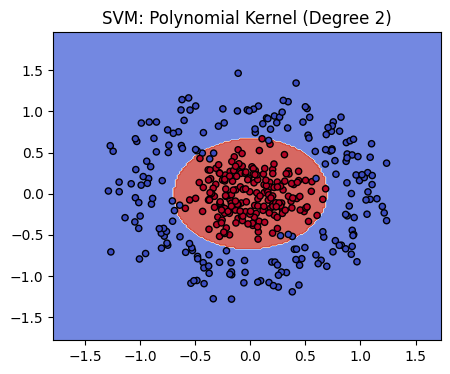

In [7]:
# Train Polynomial Kernel (Degree 2)
poly_model = SVC(kernel='poly', degree=2, C=1.0)
poly_model.fit(X_train, y_train)

# Calculate Accuracy
poly_acc = accuracy_score(y_test, poly_model.predict(X_test))
print(f"Polynomial Kernel Accuracy: {poly_acc * 100:.2f}%")

# Visualize
plt.figure(figsize=(5, 4))
Z_poly = poly_model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
plt.contourf(xx, yy, Z_poly, cmap=plt.cm.coolwarm, alpha=0.8)
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=plt.cm.coolwarm, s=20, edgecolors='k')
plt.title('SVM: Polynomial Kernel (Degree 2)')
plt.show()

Block 7: Gaussian (RBF) Kernel Implementation

RBF Kernel Accuracy: 99.00%


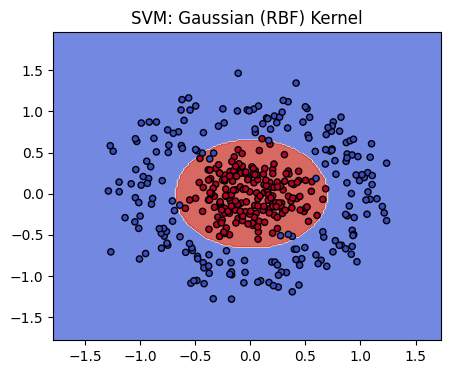

In [8]:
# Train RBF (Gaussian) Kernel
rbf_model = SVC(kernel='rbf', gamma='auto', C=1.0)
rbf_model.fit(X_train, y_train)

# Calculate Accuracy
rbf_acc = accuracy_score(y_test, rbf_model.predict(X_test))
print(f"RBF Kernel Accuracy: {rbf_acc * 100:.2f}%")

# Visualize
plt.figure(figsize=(5, 4))
Z_rbf = rbf_model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
plt.contourf(xx, yy, Z_rbf, cmap=plt.cm.coolwarm, alpha=0.8)
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=plt.cm.coolwarm, s=20, edgecolors='k')
plt.title('SVM: Gaussian (RBF) Kernel')
plt.show()

Block 8: Final Comparison

----- FINAL KERNEL COMPARISON -----

   Kernel Type  Accuracy (%)
        Linear          43.0
    Polynomial          99.0
RBF (Gaussian)          99.0


/tmp/ipykernel_633/3020552491.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Kernel Type', y='Accuracy (%)', data=results, palette='viridis')


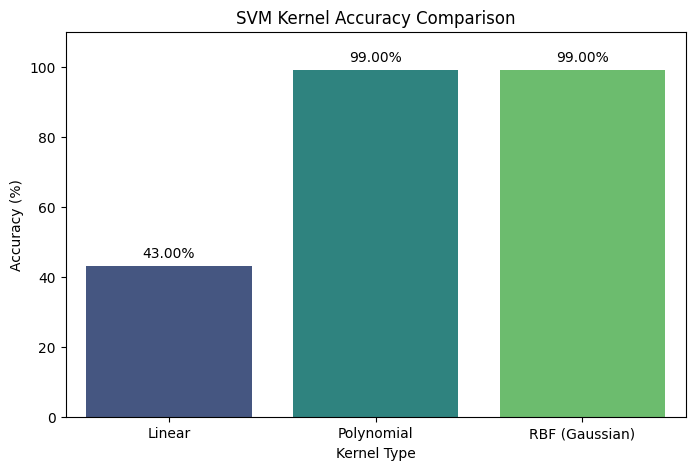

In [9]:
# Create a DataFrame for Accuracies
results = pd.DataFrame({
    'Kernel Type': ['Linear', 'Polynomial', 'RBF (Gaussian)'],
    'Accuracy (%)': [linear_acc * 100, poly_acc * 100, rbf_acc * 100]
})

print("----- FINAL KERNEL COMPARISON -----\n")
print(results.to_string(index=False))

# Plot Accuracy Comparison
plt.figure(figsize=(8, 5))
ax = sns.barplot(x='Kernel Type', y='Accuracy (%)', data=results, palette='viridis')
plt.title('SVM Kernel Accuracy Comparison')
plt.ylim(0, 110)

# Add percentage labels on top of the bars
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2f') + '%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points')

plt.show()

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


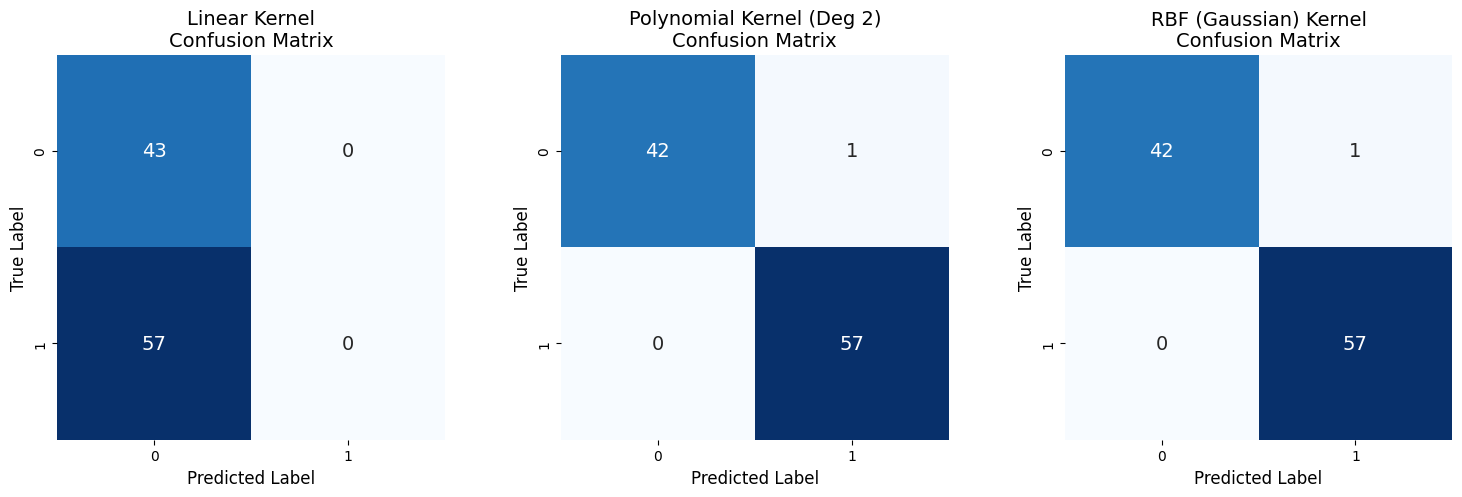


----- ADVANCED METRICS COMPARISON -----

              Kernel Type Precision Recall F1-Score
            Linear Kernel    0.0000 0.0000   0.0000
Polynomial Kernel (Deg 2)    0.9828 1.0000   0.9913
    RBF (Gaussian) Kernel    0.9828 1.0000   0.9913


In [12]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

# Corrected: We generate the predictions directly using the trained models
predictions = {
    'Linear Kernel': linear_model.predict(X_test),
    'Polynomial Kernel (Deg 2)': poly_model.predict(X_test),
    'RBF (Gaussian) Kernel': rbf_model.predict(X_test)
}

metrics_list = []

# Set up the figure for the Confusion Matrices side-by-side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plt.subplots_adjust(wspace=0.3)

for ax, (name, y_pred) in zip(axes, predictions.items()):
    # 1. Calculate Advanced Metrics
    # (Using average='binary' since we have two classes: 0 and 1)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    metrics_list.append({
        'Kernel Type': name,
        'Precision': f"{precision:.4f}",
        'Recall': f"{recall:.4f}",
        'F1-Score': f"{f1:.4f}"
    })

    # 2. Plot Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                annot_kws={"size": 14})
    ax.set_title(f'{name}\nConfusion Matrix', fontsize=14)
    ax.set_xlabel('Predicted Label', fontsize=12)
    ax.set_ylabel('True Label', fontsize=12)

plt.show()

# 3. Print the Metrics Comparison Table
metrics_df = pd.DataFrame(metrics_list)
print("\n----- ADVANCED METRICS COMPARISON -----\n")
print(metrics_df.to_string(index=False))